In [ ]:
from general_utils import find_ephys_sessions
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names, get_fitted_latent
_, _, sessions = find_ephys_sessions()
from behavior_qc_visualization import collect_behavior_model_summary
summary=collect_behavior_model_summary(sessions=['ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36'])

In [ ]:
from general_utils import find_ephys_sessions
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names, get_fitted_latent
_, _, sessions = find_ephys_sessions()
from behavior_qc_visualization import collect_behavior_model_summary
summary=collect_behavior_model_summary(sessions=sessions)

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd

from behavior_qc_visualization import collect_behavior_model_summary

def _run_one_session(session_name: str) -> pd.DataFrame:
    # If collect_behavior_model_summary can accept a single-session list, reuse it.
    # This keeps behavior identical to your existing function.
    df = collect_behavior_model_summary(sessions=[session_name])
    # Optional: add session column if it's not already present
    if "session_name" not in df.columns:
        df = df.assign(session_name=session_name)
    return df

def collect_behavior_model_summary_parallel(
    sessions,
    *,
    max_workers: int = 8,
) -> pd.DataFrame:
    dfs = []
    errors = []

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        fut_to_sess = {ex.submit(_run_one_session, s): s for s in sessions}
        for fut in as_completed(fut_to_sess):
            s = fut_to_sess[fut]
            try:
                dfs.append(fut.result())
            except Exception as e:
                errors.append((s, repr(e)))

    if errors:
        # Don't crash everything; return what you got + a helpful report
        print("Some sessions failed:")
        for s, err in errors[:20]:
            print(f"  {s}: {err}")
        if len(errors) > 20:
            print(f"  ... plus {len(errors)-20} more")

    if not dfs:
        return pd.DataFrame()

    out = pd.concat(dfs, ignore_index=True, sort=False)

    # Optional: stable ordering if you want
    if "session_name" in out.columns:
        out = out.sort_values(["session_name"]).reset_index(drop=True)

    return out

# Usage
summary = collect_behavior_model_summary_parallel(sessions, max_workers=8)


In [5]:
summary.columns

Index(['session', 'QLearning_L1F1_CK1_softmax_learn_rate_rew',
       'QLearning_L1F1_CK1_softmax_learn_rate_unrew',
       'QLearning_L1F1_CK1_softmax_forget_rate_unchosen',
       'QLearning_L1F1_CK1_softmax_choice_kernel_relative_weight',
       'QLearning_L1F1_CK1_softmax_choice_kernel_step_size',
       'QLearning_L1F1_CK1_softmax_biasL',
       'QLearning_L1F1_CK1_softmax_softmax_inverse_temperature',
       'QLearning_L1F1_CK1_softmax_learn_rate',
       'QLearning_L1F1_CK1_softmax_log_likelihood',
       'QLearning_L1F1_CK1_softmax_AIC', 'QLearning_L1F1_CK1_softmax_BIC',
       'QLearning_L1F1_CK1_softmax_LPT', 'QLearning_L1F1_CK1_softmax_LPT_AIC',
       'QLearning_L1F1_CK1_softmax_LPT_BIC',
       'QLearning_L1F1_CK1_softmax_prediction_accuracy',
       'QLearning_L1F1_CK1_softmax_reward_coefs',
       'QLearning_L2F1_softmax_learn_rate_rew',
       'QLearning_L2F1_softmax_learn_rate_unrew',
       'QLearning_L2F1_softmax_forget_rate_unchosen',
       'QLearning_L2F1_softmax_

In [34]:
import numpy as np
import pandas as pd
import ast

def sum_first_n(x, n):
    # Parse stringified lists if needed
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except Exception:
            return np.nan

    # Convert to numpy array
    arr = np.asarray(x)

    # Skip scalars / invalid entries
    if arr.ndim == 0:
        return np.nan

    # Require at least n elements
    if arr.size < n:
        return np.nan

    return float(arr[:n].sum())


# --------------------------------------------------
# Models to process
# --------------------------------------------------
models = [
    "QLearning_L1F1_CK1_softmax",
    "QLearning_L2F1_softmax",
    "QLearning_L2F1_CK1_softmax",
    "QLearning_L2F1_CKfull_softmax",
    "ForagingCompareThreshold",
]

# Number of coefficients to sum
n = 6


# --------------------------------------------------
# Apply for all models
# --------------------------------------------------
for model in models:
    src_col = f"{model}_reward_coefs"
    dst_col = f"{model}_reward_coefs_sum{n}"

    if src_col not in summary.columns:
        print(f"⚠️  Skipping {model}: column '{src_col}' not found")
        continue

    summary[dst_col] = summary[src_col].apply(sum_first_n, n=n)


In [30]:
summary["QLearning_L2F1_CK1_softmax_LPT"] 

0     0.724035
1     0.619230
2     0.691659
3     0.665012
4     0.718260
5     0.564360
6     0.558015
7     0.569721
8     0.830714
9     0.770138
10    0.767297
11    0.760441
12    0.794498
13    0.815374
14    0.725232
15    0.776754
16    0.804130
17    0.811322
18    0.820806
19    0.736392
20    0.681293
21    0.690567
22         NaN
23    0.776516
24    0.851327
25    0.853246
26         NaN
27         NaN
28         NaN
29         NaN
30         NaN
31         NaN
32         NaN
33         NaN
34         NaN
35         NaN
36         NaN
37         NaN
38         NaN
39         NaN
40         NaN
Name: QLearning_L2F1_CK1_softmax_LPT, dtype: float64

In [31]:
summary["QLearning_L2F1_CK1_softmax_reward_coefs_sum6"] 

0     0.576996
1     0.754949
2     0.538131
3     0.978789
4     0.827749
5     0.819316
6     0.926726
7     0.939889
8     0.178842
9     0.021380
10    0.061923
11    0.670595
12    0.442117
13    0.488938
14    0.548057
15    0.561832
16    0.390752
17    0.689446
18    0.411542
19    0.496159
20    0.333026
21    0.678748
22         NaN
23    0.570166
24    0.328159
25    0.094625
26         NaN
27         NaN
28         NaN
29         NaN
30         NaN
31         NaN
32         NaN
33         NaN
34         NaN
35         NaN
36         NaN
37         NaN
38         NaN
39         NaN
40         NaN
Name: QLearning_L2F1_CK1_softmax_reward_coefs_sum6, dtype: float64

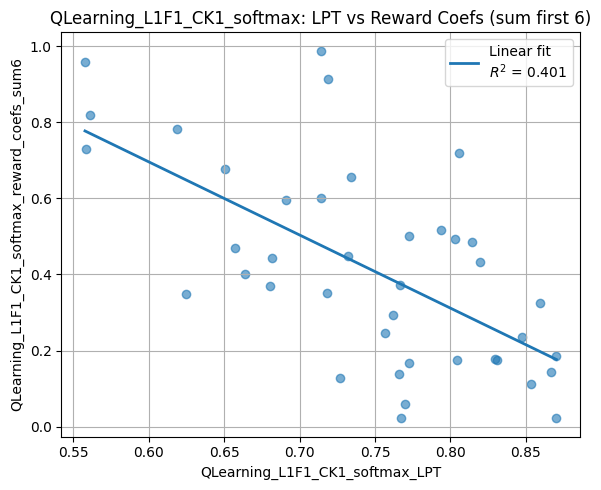

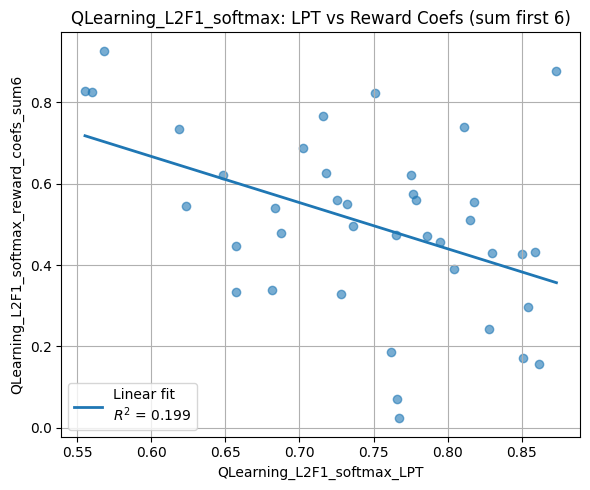

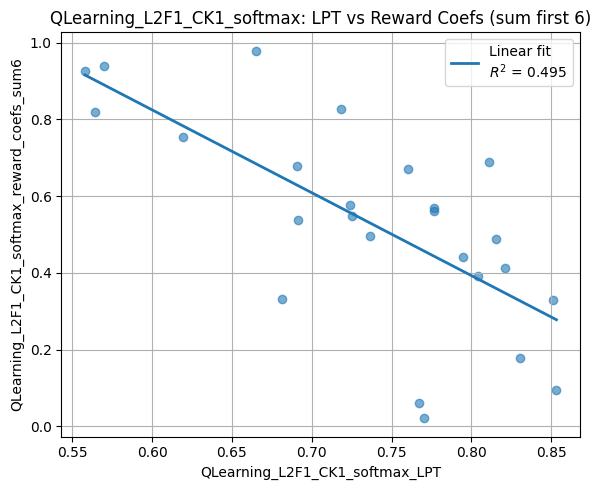

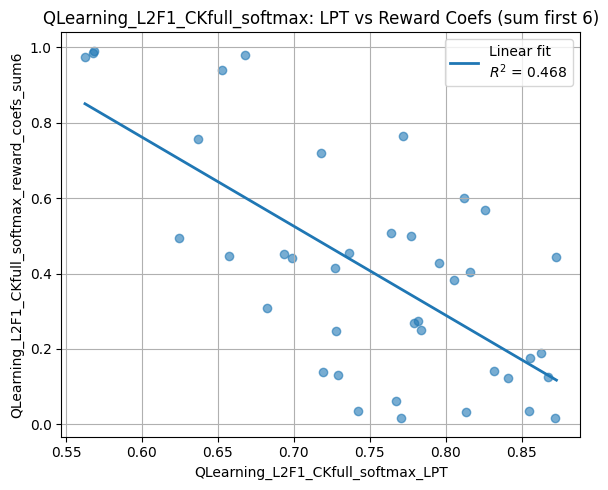

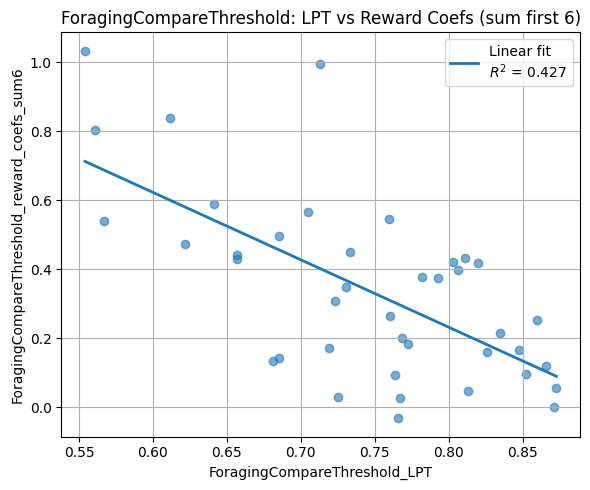

In [37]:
import numpy as np
import matplotlib.pyplot as plt

models = [
    "QLearning_L1F1_CK1_softmax",
    "QLearning_L2F1_softmax",
    "QLearning_L2F1_CK1_softmax",
    "QLearning_L2F1_CKfull_softmax",
    "ForagingCompareThreshold",
]

for model in models:
    x_col = f"{model}_LPT"
    y_col = f"{model}_reward_coefs_sum6"

    if x_col not in summary.columns or y_col not in summary.columns:
        print(f"Skipping {model}: missing columns")
        continue

    # Drop NaNs pairwise
    df = summary[[x_col, y_col]].dropna()
    x = df[x_col].values
    y = df[y_col].values

    if len(x) < 3:
        print(f"Skipping {model}: not enough data points")
        continue

    # Linear fit
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept

    # Goodness of fit (R^2)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # Plot
    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, alpha=0.6)
    plt.plot(
        np.sort(x),
        slope * np.sort(x) + intercept,
        linewidth=2,
        label=f"Linear fit\n$R^2$ = {r2:.3f}",
    )
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{model}: LPT vs Reward Coefs (sum first 6)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"{model}: slope={slope:.4f}, intercept={intercept:.4f}, R^2={r2:.4f}")
